# **Model training**

Using the scripts inside `src` directory we can perform any kind of experiment starting from data generation to model evaluation, and drift detection(data, target, concept)

- To maintain consistancy in filenames(csv, model, threashold, html, png) I have included a seed number during data generation, and it will be there in every filename only if you generate a dataset or use an existing dataset the naming would be for example `filename_seed_xx`.


- Generated the data will be stored inside the `data/simulated` and features will be stored in `data/features` directory.

- Models will stored in `artifacts/models` and thresholds will be inside `artifacts/model_threshold` directory.

- Execute the scripts in the following order, don't change it. But it possible to change the parameters of the functions.

## 1. Generate the data for training
This is where all starts, this function will generate 10_000 transactions of 500 users, with a seed number 42 by default. Change the `seed` parameter to get different dataset. It is also possible to change the number of transactions and users.

In [10]:
from fraud_detection import generate_transactions_data 

df = generate_transactions_data()
df.head()

Name of the csv file: 'simulated_transactions_seed_42.csv'

Data saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/data/simulated/simulated_transactions_seed_42.csv

Generated 10000 transactions.
Fraud rate: 1.48%


,tx_id,timestamp,user_id,amount,category,device_id,auth_method,lat,lon,ip_address,is_fraud
0,e4fd6c34-d67,2026-01-18 05:27:27.512537,user_55,172.43,grocery,475287aa,PIN,-83.615968,174.348649,120.185.31.102,0
1,0cb5ee5c-62f,2026-01-17 08:30:09.171284,user_407,8.43,food,379d58f9,Biometric,20.500359,150.789724,107.109.217.82,0
2,39a0f145-a5b,2026-02-11 03:14:34.561769,user_142,1259.07,tech,bea29dfe,PIN,-87.864685,123.877867,145.56.170.82,0
3,052226b9-836,2026-01-15 11:32:43.597999,user_492,26.14,grocery,052dfb9a,Biometric,-0.992383,-52.469217,208.72.228.108,0
4,a5ba2472-21d,2026-01-24 23:13:11.816576,user_261,364.83,utilities,0d18ab95,Biometric,8.142126,36.488989,104.34.170.221,0


## 2. Perform feature engineering
Just take the name of the csv file with quotes from above cell output and use it as a parameter in feature engineering function, and you will get the model ready features.

In [11]:
from fraud_detection import feature_engineering

df = feature_engineering(
    'simulated_transactions_seed_42.csv'
)

df.head()

Name of the csv file: 'fraud_features_seed_42.csv'

Saved at: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/data/features/fraud_features_seed_42.csv

No of rows: 10000
No of columns: 18


,amount,lat,lon,is_fraud,hour,day_of_week,tx_count_24h,avg_spend_user,amount_ratio,dist_from_last_tx_km,travel_velocity_kmph,auth_method_PIN,auth_method_Password,category_food,category_grocery,category_tech,category_travel,category_utilities
0,347.15,81.605220,-120.226604,0,13,0,1.0,0.000000,0.000000,0.000000,0.0,False,False,False,False,False,False,True
1,232.72,81.664590,-120.236689,0,12,1,2.0,347.150000,0.670373,6.603658,0.0,True,False,False,False,False,False,True
2,260.47,81.612479,-120.228856,0,21,1,2.0,289.935000,0.898374,5.795863,0.0,False,True,False,False,False,False,True
3,103.94,81.600013,-120.252652,0,11,2,3.0,280.113333,0.371064,1.438964,0.0,False,False,True,False,False,False,False
4,2897.77,81.599709,-120.249781,0,1,3,2.0,236.070000,12.275046,0.057599,0.0,False,True,False,False,True,False,False


## 3. Model Training

- Just take the name of the csv file with quotes from above cell output and use it as a parameter in `model_trainer` function.

- `model_trainer` function will return two output one is testing features `X_test` and other one is target `y_test`, keep them for further use. **Don't worry the model will be trained, just click on the path, you will see it.**

- Currently there are two algo in the `config.yaml` file, `RandomForestClassifier` and `XGBClassifier`. The script will perform a grid serach so it may take some time. Also it is possible to add another algo in the `config.yaml` file. 

In [12]:
from fraud_detection import model_trainer

X_test, y_test = model_trainer(
    'fraud_features_seed_42.csv'
)

Running GridSearch for: random_forest
Model Name: 'random_forest_seed_42.json'
Best Score: 0.9992 | Saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/models
Running GridSearch for: xgboost
Model Name: 'xgboost_seed_42.json'
Best Score: 0.9978 | Saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/models


## 4. Business-cost-aware Thresholding (Threshold Optimization) 
Q. Why is this necessary?

A. Not catching a fraud is much more deadly than blocking a legitamite transaction. ***Considering them as equal, is like commiting warcrimes on our customers***.

Inevitably, xgboost treats both of these errors equally because of it's fixed threshold 0.5, ***going down that path would lead us to loose money and trust***. 

So we need a custom decision boundary that ***prioritize catching fraud***.

- The variables you put above will be used here in this function `threshold_optimizer` as a parameter.

- `threshold_optimizer` will return two values, first one is probability of that particular model on test data, the second one is using the threshold make a final prediction. Put this two values inside two variables. But don't just use `y_prob` and `y_pred_final` as variable name. Just put the the name of the model after underscore `_`. 

- Now this two new variable and the previous two variable will be used to evaluate a model.


### a. Optimize threshold xgboost

In [13]:
from fraud_detection import threshold_optimizer

y_prob_xgb , y_pred_final_xgb = threshold_optimizer(
    X_test, 
    y_test, 
    'xgboost_seed_42.json'    
)

Optimal threshold information saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/model_thresholds

The threshold for the model: xgboost_seed_42 is: 0.97


### b. Optimize threshold RandomForest

In [14]:
from fraud_detection import threshold_optimizer

y_prob_rf , y_pred_final_rf = threshold_optimizer(
    X_test,
    y_test,
    'random_forest_seed_42.json'
)

Optimal threshold information saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/model_thresholds

The threshold for the model: random_forest_seed_42 is: 0.39


## 5. Model Evaluation

### a. Evaluate the xgboost model

AUC-PR for xgboost_seed_42.json: 1.0000

Classification Report for xgboost_seed_42.json:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/src/fraud_detection/model_evaluation.py:121: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  


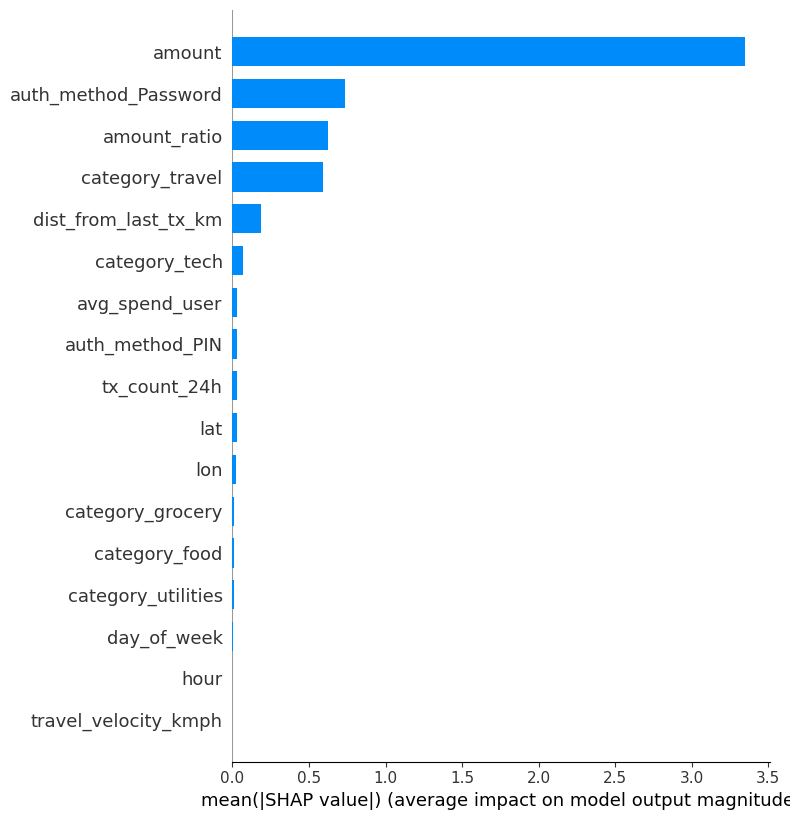

In [15]:
from fraud_detection import model_evaluator

model_evaluator(
    'xgboost_seed_42.json',
    X_test,
    y_test,
    y_prob_xgb,
    y_pred_final_xgb
)

### b. Evaluate the RandomForest Model

AUC-PR for random_forest_seed_42.json: 1.0000

Classification Report for random_forest_seed_42.json:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/src/fraud_detection/model_evaluation.py:121: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  


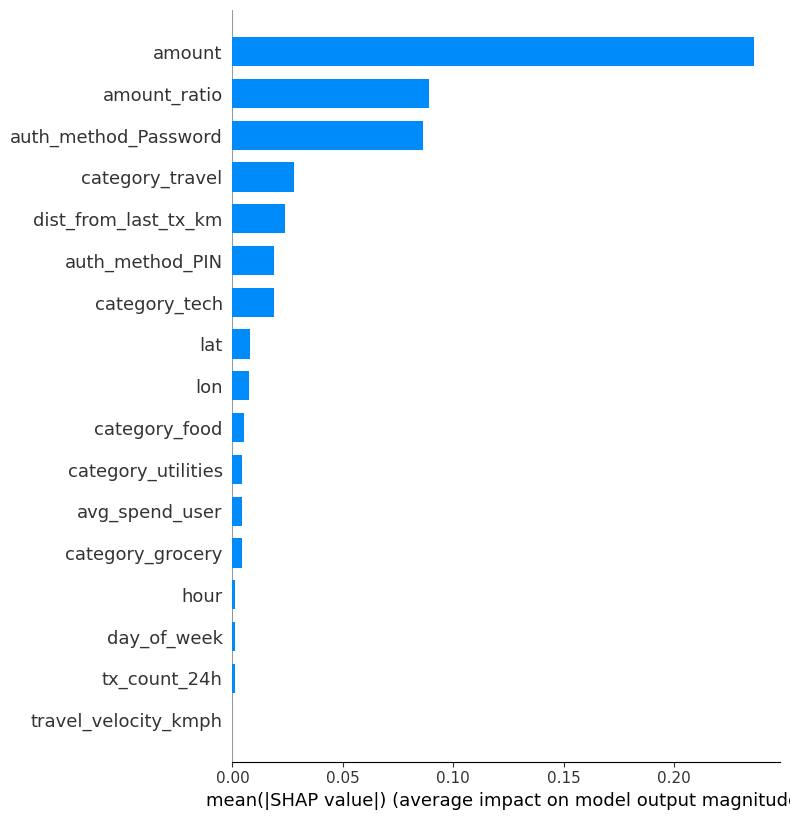

In [16]:
from fraud_detection import model_evaluator

model_evaluator(
    'random_forest_seed_42.json',
    X_test,
    y_test,
    y_prob_rf,
    y_pred_final_rf
)